In [32]:
from misc_utils import hadamard_transform
import numpy as np
from spin_lattices import KagomeLattice
from spin_systems import (
    heisenberg,
    heisenberg_transversal_field,
    spin_system,
    no_symmetries_basis,
    LatticeExpr
)
from spin_lattices import KagomeLattice

# from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
import numpy as np
from hadamard_learning import evaluate_hadamard_learning_test_set
from tqdm.auto import tqdm
import pandas as pd
import seaborn as sns

In [43]:
lattice = KagomeLattice(2, 4)
J2 = 0.3
expr1 = LatticeExpr(lattice, edge_str="2 (σ⁺₀ σ⁻₁ + σ⁺₁ σ⁻₀) + σᶻ₀ σᶻ₁", edge_params={1: 1, 2: J2}).expr
expr2 = LatticeExpr(lattice, edge_str="0.5 (σˣ₀ + σᶻ₀)(σˣ₁ + σᶻ₁)(σ⁺₀ σ⁻₁ + σ⁺₁ σ⁻₀)(σˣ₀ + σᶻ₀)(σˣ₁ + σᶻ₁) + 0.25 (σˣ₀ + σᶻ₀)(σˣ₁ + σᶻ₁)σᶻ₀ σᶻ₁(σˣ₀ + σᶻ₀)(σˣ₁ + σᶻ₁)", edge_params={1: 1, 2: J2}).expr

In [44]:
expr1 == expr2

True

In [2]:
lattice = KagomeLattice(2, 4)
outputs = []
sample_power = 2

for h in tqdm(np.linspace(0, 1, 21)):
    for J2 in [0.3, 1]:
        system = spin_system(
            heisenberg_transversal_field(lattice, J2=J2, h=h),
            no_symmetries_basis(hamming_weight=None, spin_inversion=None),
        )
        wavefunction = system.ground_state
        transformed_wavefunction = hadamard_transform(wavefunction)
        outputs.append(
            evaluate_hadamard_learning_test_set(
                wavefunction=wavefunction,
                basis=system.basis,
                sample_power=sample_power,
                test_size=50000,
                eps_train=1e-2,
            )
            | {
                "h": h,
                "lattice": "kagome2x4",
                "overlap_with_transformed": transformed_wavefunction
                @ wavefunction
                / np.linalg.norm(wavefunction)
                / np.linalg.norm(transformed_wavefunction),
                "J2": J2,
            }
        )


2024-09-25 19:36:17.007 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2024-09-25 19:36:17.008 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-09-25 19:36:17.067 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-09-25 19:36:17.232 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-09-25 19:36:17.336 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-09-25 19:36:17.414 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-09-25 19:36:17.482 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-09-25 19:36:17.547 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-09-25 19:36:17.621 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-09-25 19:36:17.692 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-0

In [12]:
spin_system(
    heisenberg_transversal_field(lattice, J2=0.3, h=0),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
).ground_energy

2024-09-25 19:56:21.805 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.


-42.07430858877421

In [88]:
J2 = 0.8

In [90]:
gs = np.zeros(2 ** lattice.number_spins)
system = spin_system(
    heisenberg(lattice, J2=J2),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)
#gs[system.basis.states] = system.ground_state


In [91]:
system.get_eigenstates(2)

2024-09-25 20:52:17.971 | DEBUG    | spin_systems:get_eigenstates:226 - Calculating eigenvalues / eigenstates
2024-09-25 21:07:49.101 | DEBUG    | spin_systems:get_eigenstates:237 - Ground state energy is -40.6362241107


(array([-40.63622411, -40.51834201]),
 array([[-4.60058596e-17,  1.76833790e-17],
        [-2.25457090e-17,  9.97852621e-18],
        [-2.26436508e-17,  1.23441068e-17],
        ...,
        [-1.29392732e-17,  3.78279772e-18],
        [-1.57242797e-17,  5.54081108e-18],
        [-1.06944149e-16,  2.87880069e-17]]))

In [83]:
transformed = hadamard_transform(gs)

2024-09-25 20:45:31.659 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-09-25 20:45:31.719 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-09-25 20:45:31.882 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-09-25 20:45:31.986 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-09-25 20:45:32.063 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-09-25 20:45:32.131 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-09-25 20:45:32.195 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-09-25 20:45:32.269 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-09-25 20:45:32.341 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-09-25 20:45:32.410 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 10.0 of 24.0
2024-09-25 20:45:32.472 | DEBUG    | misc_utils:h

In [84]:
gs @ transformed / np.linalg.norm(gs) / np.linalg.norm(transformed)

0.37499999999999994

In [77]:
system_nosym = spin_system(
    heisenberg(lattice, J2=J2),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)
states = system_nosym.basis.states
gs_nosym = system_nosym.get_ground_state_coeffs(states, apply_symmetries=False)
gs_sym = system.get_ground_state_coeffs(
    states, apply_symmetries=True
)

2024-09-25 20:41:25.419 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.


IndexError: index 0 is out of bounds for axis 0 with size 0

In [46]:
J2 = 0.3
system = spin_system(
    heisenberg(lattice, J2=J2),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)
eps_train = 1e-2
evaluate_hadamard_learning_test_set(
    wavefunction=system.ground_state,
    basis=system.basis,
    sample_power=sample_power,
    test_size=50000,
    eps_train=eps_train,
)

2024-09-25 20:26:51.799 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.


{'sample_size': 157048,
 'eps_train': 0.01,
 'sample_power': 2,
 'test_size': 50000,
 'accuracy_test': 0.48851,
 'sign_overlap_test': -0.339729668276139}

In [30]:
system_heisenberg = spin_system(
    heisenberg(lattice, J2=0.4),
    no_symmetries_basis(hamming_weight=None, spin_inversion=None),
)

In [31]:
transformed = hadamard_transform(system_heisenberg.ground_state)
system_heisenberg.ground_state @ transformed / np.linalg.norm(transformed) / np.linalg.norm(
    system_heisenberg.ground_state
)

2024-09-25 20:09:57.487 | DEBUG    | spin_systems:get_eigenstates:226 - Calculating eigenvalues / eigenstates
2024-09-25 20:12:04.871 | DEBUG    | spin_systems:get_eigenstates:237 - Ground state energy is -40.7607708401
2024-09-25 20:12:04.873 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-09-25 20:12:04.931 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-09-25 20:12:05.097 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-09-25 20:12:05.201 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-09-25 20:12:05.277 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-09-25 20:12:05.344 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-09-25 20:12:05.408 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-09-25 20:12:05.482 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-09-25 20:12:05.

0.029003381426328516

In [11]:
pd.DataFrame(outputs)

,sample_size,eps_train,sample_power,test_size,accuracy_test,sign_overlap_test,h,lattice,overlap_with_transformed,J2
0,157048,0.01,2,50000,0.49122,-0.323152,0.00,kagome2x4,0.056272,0.3
1,24209,0.01,2,50000,0.51704,0.973750,0.00,kagome2x4,1.000000,1.0
2,157048,0.01,2,50000,0.49621,-0.048914,0.05,kagome2x4,0.062500,0.3
3,24209,0.01,2,50000,0.52000,0.971049,0.05,kagome2x4,1.000000,1.0
4,157048,0.01,2,50000,0.50046,-0.007092,0.10,kagome2x4,0.062500,0.3
5,24209,0.01,2,50000,0.51340,0.978596,0.10,kagome2x4,1.000000,1.0
6,157048,0.01,2,50000,0.49369,-0.054595,0.15,kagome2x4,0.062500,0.3
7,24209,0.01,2,50000,0.51660,0.975543,0.15,kagome2x4,1.000000,1.0
8,157048,0.01,2,50000,0.49378,-0.025848,0.20,kagome2x4,0.062500,0.3
9,24209,0.01,2,50000,0.52000,0.978501,0.20,kagome2x4,1.000000,1.0


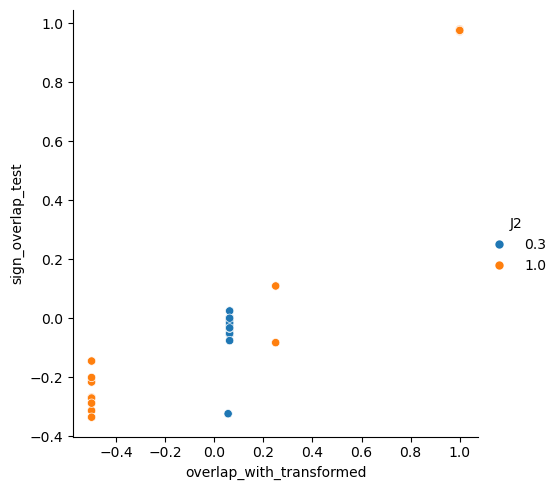

In [10]:
sns.relplot(
    pd.DataFrame(outputs).astype({'J2': str}),
    x="overlap_with_transformed",
    y="sign_overlap_test",
    hue="J2",
  #  kind="line",
)